# HSBC PB Case Challenge 2026 — Calculation Engine

## How to Use This Notebook

1. **Cell 1 (Data)** contains all fund data from Appendix I & II. Do not modify.
2. **Cell 2 (Parameters)** is the only cell you need to edit. Change values here after team discussion.
3. **Cells 3–8** run all calculations automatically. After editing Cell 2, go to **Kernel → Restart & Run All**.

Currently, only **Cell 3 (No-Parameter Calculations)** produces meaningful output. All other cells will update once parameters are filled in.


---
## Cell 1: Fund Universe Data (Fixed)

All fund data from Appendix I and Appendix II, exactly as provided in the case. This cell should never be modified.

- **Annualized Return**: 5-year annualized total return (including yield for alternatives)
- **Annualized Volatility**: 5-year annualized standard deviation
- **AR (Advance Ratio)**: Maximum percentage of fund value that HSBC will lend against as collateral
- **Correlation**: Only available for Appendix II alternatives — correlation with their respective benchmark
- **Min Investment**: Minimum subscription amount (only for Appendix II)
- **Max Quarterly Redemption**: Maximum percentage redeemable per quarter (only for Appendix II — fixed at 12.5%)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)

# ── Appendix I: Traditional Funds ──

app1_data = {
    "ISIN": [
        "LU0079474960","LU0823410997","LU0210528500","LU0210536511","LU0674140396",
        "LU1153584641","LU0171276677","LU0997586606","LU1193295406","LU0336375786",
        "LU0006061252","LU0129465034","LU1684384271","LU0936264273","LU1453624402",
        "IE00B067MR52","LU0197773160","HK0000055555","LU0188438112","LU0390135332",
        "LU1728044204","LU1128926489","IE00B8K7V925","LU1514167136",
        "LU1008669860","LU0171284770","LU0780247044","LU0418832605",
        "LU0200680600","LU0605512275","LU0562246024",
        "LU0679941327","LU0780247804","LU0692309627",
        "LU1548497426","LU0124384867","LU0106831901","LU0055631609","LU0109394709",
        "IE0009355771","LU0070992663","LU0101692670","LU1861558580","LU1983299162"
    ],
    "Fund": [
        "AB American Growth Portfolio","BNP US Small Cap","JPMorgan America Equity Fund",
        "JPMorgan US Value","Robeco US Select Opportunities Equity",
        "BlackRock European Equity Income","BlackRock European Special Situations Fund",
        "Fidelity European Growth Fund","HSBC GIF Euroland Value Equity","JPMorgan Europe Equity Plus",
        "BlackRock Japan Small & Midcap Opportunities","JPMorgan Japan","M&G Japan",
        "Pictet Japanese Equity Opportunities","Schroder Japanese Equity",
        "FSSA Asian Equity Plus","HSBC Asia ex Japan Equity High Dividend","JPMorgan ASEAN",
        "Schroder Asian Equity Yield","Templeton Asian Smaller Companies",
        "HSBC Global IG Securitised Credit","JPMorgan Income","PIMCO Income","Schroder Global Credit Income",
        "AB Global High Yield","BlackRock Global High Yield Bond","HSBC Global High Yield Bond","Schroder Global High Yield",
        "BlackRock Emerging Markets Bond","Fidelity Asian Bond","JPMorgan EM Investment Grade",
        "BlackRock China Bond","HSBC GIF India Fixed Income","HSBC GIF RMB Fixed Income",
        "Allianz Global AI","BlackRock Sustainable Energy","BlackRock World Financials",
        "BlackRock World Gold","Franklin Biotechnology Discovery","Janus Henderson Global Life Sciences",
        "Janus Henderson Global Technology Leaders","Pictet Digital",
        "Nikko AM ARK Disruptive Innovation","Schroder Global Alternative Energy"
    ],
    "Asset Class": [
        "US Equities","US Equities","US Equities","US Equities","US Equities",
        "European Equities","European Equities","European Equities","European Equities","European Equities",
        "Japanese Equities","Japanese Equities","Japanese Equities","Japanese Equities","Japanese Equities",
        "Asia ex-Japan Equities","Asia ex-Japan Equities","Asia ex-Japan Equities","Asia ex-Japan Equities","Asia ex-Japan Equities",
        "Global IG Bonds","Global IG Bonds","Global IG Bonds","Global IG Bonds",
        "Global HY Bonds","Global HY Bonds","Global HY Bonds","Global HY Bonds",
        "EM Hard Currency Debt","EM Hard Currency Debt","EM Hard Currency Debt",
        "EM Local Currency Debt","EM Local Currency Debt","EM Local Currency Debt",
        "Thematic","Thematic","Thematic","Thematic","Thematic","Thematic","Thematic","Thematic","Thematic","Thematic"
    ],
    "Return": [
        0.126,0.080,0.144,0.106,0.107,
        0.107,0.022,0.101,0.165,0.157,
        0.051,0.037,0.126,0.180,0.036,
        0.026,0.077,0.058,0.087,0.088,
        0.035,0.023,0.032,0.024,
        0.039,0.034,0.024,0.038,
        0.032,0.010,-0.002,
        0.014,0.004,0.004,
        0.070,0.071,0.191,0.145,0.052,0.056,0.158,0.032,-0.027,-0.005
    ],
    "Volatility": [
        0.182,0.204,0.156,0.148,0.180,
        0.130,0.206,0.122,0.167,0.162,
        0.143,0.194,0.143,0.124,0.141,
        0.158,0.160,0.145,0.167,0.155,
        0.020,0.043,0.057,0.063,
        0.073,0.067,0.066,0.069,
        0.098,0.098,0.075,
        0.107,0.050,0.060,
        0.257,0.212,0.242,0.305,0.199,0.154,0.206,0.057,0.420,0.263
    ],
    "AR": [
        0.70,0.70,0.70,0.70,0.70,
        0.70,0.70,0.70,0.70,0.70,
        0.70,0.70,0.70,0.70,0.70,
        0.70,0.70,0.70,0.70,0.70,
        0.80,0.70,0.80,0.80,
        0.60,0.70,0.60,0.70,
        0.75,0.75,0.80,
        0.75,0.75,0.80,
        0.70,0.70,0.70,0.70,0.70,0.70,0.75,0.70,0.70,0.70
    ]
}

funds = pd.DataFrame(app1_data).set_index("ISIN")

# ── Appendix II: Alternative Funds ──

app2_data = {
    "Fund": [
        "Global Private Equity Fund","Global Private Credit Fund",
        "Global Infrastructure Income Fund","US Core Plus Real Estate Income Fund",
        "Global Multi-Strategy Multi-PM","Global Equity L/S","Asia Equity L/S",
        "Global Macro","Global Fund of Hedge Funds"
    ],
    "Type": [
        "Private Markets","Private Markets","Private Markets","Private Markets",
        "Hedge Fund","Hedge Fund","Hedge Fund","Hedge Fund","Hedge Fund"
    ],
    "Correlation": [0.17, 0.35, 0.52, 0.56, 0.21, 0.29, 0.33, -0.24, 0.66],
    "Benchmark": [
        "MSCI World","ICE BofA US High Yield","S&P Global Infra. Index","D.J. US Real Estate",
        "MSCI World","MSCI World","MSCI Asia Pacific","MSCI World","MSCI World"
    ],
    "Return": [0.099, 0.082, 0.080, 0.089, 0.103, 0.144, 0.196, 0.094, 0.046],
    "Volatility": [0.196, 0.136, 0.110, 0.113, 0.068, 0.101, 0.107, 0.058, 0.033],
    "AR": [0.50, 0.50, 0.50, 0.50, 0.40, 0.40, 0.40, 0.40, 0.40],
    "Min Investment": [150000,150000,150000,150000,250000,250000,250000,250000,250000],
    "Max Quarterly Redemption": [0.125]*9
}

alts = pd.DataFrame(app2_data)

# ── Client's Current Portfolio ──

current_portfolio = pd.DataFrame({
    "Asset Class": ["US Equities","HK Equities","SG Equities","Global HY Bonds","Cash"],
    "Weight": [0.70, 0.05, 0.03, 0.02, 0.20]
})

# ── Client's External Assets (for Credit Solution) ──

external_assets = pd.DataFrame({
    "Asset": ["LionDash Shares","Singapore Commercial Property","Fine Art"],
    "Value": [30_000_000, 15_000_000, 5_000_000],
    "Standard AR": [0.50, 0.50, 0.75]
})

print("Data loaded successfully.")
print(f"Appendix I: {len(funds)} funds across {funds['Asset Class'].nunique()} asset classes")
print(f"Appendix II: {len(alts)} alternative funds")


ModuleNotFoundError: No module named 'seaborn'

---
## Cell 2: Parameters

**This is the only cell you need to edit.** All values below require team discussion before filling in. After editing, go to Kernel → Restart & Run All.

Each parameter has a description and a placeholder value. Replace placeholders with agreed-upon values.

### Parameter Descriptions

| Parameter | What It Is | Why We Need It |
|---|---|---|
| `rf_rate` | Risk-free rate (e.g., US T-bill yield) | Denominator baseline for Sharpe ratio |
| `borrowing_cost` | Annual interest rate HSBC charges on Lombard loans | Needed to calculate true leveraged returns |
| `income_target` | Annual income Mr. Seng wants from his portfolio | To verify if our allocation meets his income needs |
| `total_investment` | Total amount Mr. Seng wants to invest | Fixed at $80M per case |
| `investable_cash` | Mr. Seng's available cash for investment | Fixed at $45M per case |
| `asset_class_benchmarks` | Proxy return/vol/yield for each broad asset class | Used to estimate current portfolio performance |
| `correlation_matrix` | Correlation between asset classes | Needed to calculate portfolio volatility |
| `saa_weights` | Strategic Asset Allocation — long-term target weights | Core deliverable |
| `taa_weights` | Tactical Asset Allocation — short-term adjusted weights | Core deliverable |
| `fund_selection` | Which specific funds to include in the portfolio | Maps funds to asset classes |
| `fund_weights` | Weight of each selected fund within its asset class | Needed for portfolio-level calculations |
| `yield_assumptions` | Estimated income yield for each selected fund | To separate cash return from capital gain |
| `collateral_scenario` | Which external assets to pledge as collateral | Determines borrowing capacity |


In [ ]:
# ════════════════════════════════════════════════════════════
# PARAMETERS — EDIT THIS CELL ONLY
# ════════════════════════════════════════════════════════════

# ── Risk & Cost Assumptions ──
rf_rate = 0.045           # placeholder
borrowing_cost = 0.055    # placeholder

# ── Client Targets (from case) ──
income_target = 300_000
total_investment = 80_000_000
investable_cash = 45_000_000

# ── Current Portfolio Benchmark Proxies ──
# Format: { "Asset Class": (expected_return, volatility, estimated_yield) }
asset_class_benchmarks = {
    "US Equities":      (0.10,  0.16, 0.013),   # placeholder — e.g. S&P 500
    "HK Equities":      (0.06,  0.20, 0.030),   # placeholder — e.g. Hang Seng
    "SG Equities":      (0.05,  0.15, 0.035),   # placeholder — e.g. STI
    "Global HY Bonds":  (0.04,  0.07, 0.060),   # placeholder — e.g. ICE BofA HY
    "Cash":             (0.045, 0.00, 0.045),    # placeholder — money market rate
}

# ── Correlation Matrix (across broad asset classes) ──
# Order: US Eq, HK Eq, SG Eq, Global HY, Cash
correlation_matrix = np.array([
    [1.00, 0.70, 0.65, 0.30, 0.00],   # placeholder values
    [0.70, 1.00, 0.80, 0.25, 0.00],
    [0.65, 0.80, 1.00, 0.25, 0.00],
    [0.30, 0.25, 0.25, 1.00, 0.00],
    [0.00, 0.00, 0.00, 0.00, 1.00],
])

# ── SAA & TAA Weights ──
# Format: { "Asset Class": weight }
# Must sum to 1.0
saa_weights = {
    "US Equities": 0.0,
    "European Equities": 0.0,
    "Japanese Equities": 0.0,
    "Asia ex-Japan Equities": 0.0,
    "Global IG Bonds": 0.0,
    "Global HY Bonds": 0.0,
    "EM Hard Currency Debt": 0.0,
    "EM Local Currency Debt": 0.0,
    "Government Bonds": 0.0,
    "Private Markets": 0.0,
    "Hedge Funds": 0.0,
    "Thematic": 0.0,
    "Cash": 0.0,
}

taa_weights = {k: 0.0 for k in saa_weights}

# ── Fund Selection ──
# Format: { "ISIN or Fund Name": (asset_class, weight_within_portfolio, estimated_yield) }
# weight_within_portfolio = the fund's share of total portfolio (must sum to 1.0 across all funds)
# estimated_yield = estimated annual income yield (cash return component)
fund_selection = {
    # "LU0210528500": ("US Equities", 0.10, 0.012),   # example
}

# ── Alternative Fund Selection ──
# Format: { "Fund Name": (weight_within_portfolio, estimated_yield) }
alt_selection = {
    # "Global Equity L/S": (0.05, 0.00),   # example
}

# ── Collateral Scenario for Credit Solution ──
# True = pledge this asset, False = do not pledge
collateral_scenario = {
    "LionDash Shares": False,               # placeholder
    "Singapore Commercial Property": False,  # placeholder
    "Fine Art": False,                       # placeholder
}

# ── New Portfolio Correlation Matrix ──
# Full correlation matrix across ALL asset classes used in SAA/TAA
# Order must match the keys in saa_weights (excluding zero-weight classes)
# For now this is a placeholder — fill in after deciding allocation
new_portfolio_corr = None  # replace with np.array([...]) when ready

print("Parameters loaded. Current status:")
saa_sum = sum(saa_weights.values())
taa_sum = sum(taa_weights.values())
fund_sum = sum(v[1] for v in fund_selection.values()) + sum(v[0] for v in alt_selection.values())
print(f"  SAA weights sum: {saa_sum:.1%} {'✓' if abs(saa_sum - 1.0) < 0.001 else '✗ (must be 100%)'}")
print(f"  TAA weights sum: {taa_sum:.1%} {'✓' if abs(taa_sum - 1.0) < 0.001 else '✗ (must be 100%)'}")
print(f"  Fund weights sum: {fund_sum:.1%} {'✓' if abs(fund_sum - 1.0) < 0.001 else '✗ (must be 100%)'}")


Parameters loaded. Current status:
  SAA weights sum: 0.0% ✗ (must be 100%)
  TAA weights sum: 0.0% ✗ (must be 100%)
  Fund weights sum: 0.0% ✗ (must be 100%)


---
## Cell 3: Calculations That Need No Parameters

These results use only the raw data from Appendix I & II — no assumptions required.

### What is Return / Volatility Ratio?

A simple efficiency measure: how much return does a fund generate per unit of risk? Higher is better. This is **not** the Sharpe ratio (which subtracts the risk-free rate). It gives a quick first look at which funds are most efficient within each asset class.


In [ ]:
# ── Return / Volatility Ratio ──

funds["Return/Vol"] = funds["Return"] / funds["Volatility"]

for ac in funds["Asset Class"].unique():
    subset = funds[funds["Asset Class"] == ac].copy()
    subset["Rank"] = subset["Return/Vol"].rank(ascending=False).astype(int)
    funds.loc[subset.index, "Rank in Class"] = subset["Rank"]

funds["Rank in Class"] = funds["Rank in Class"].astype(int)

display_cols = ["Fund","Asset Class","Return","Volatility","AR","Return/Vol","Rank in Class"]

print("=" * 80)
print("APPENDIX I — FUND EFFICIENCY RANKINGS")
print("=" * 80)

for ac in funds["Asset Class"].unique():
    subset = funds[funds["Asset Class"] == ac][display_cols].sort_values("Return/Vol", ascending=False)
    print(f"\n▸ {ac}")
    print(subset.to_string(index=True))
    print()


APPENDIX I — FUND EFFICIENCY RANKINGS

▸ US Equities
                                               Fund  Asset Class  Return  Volatility   AR  Return/Vol  Rank in Class
ISIN                                                                                                                
LU0210528500           JPMorgan America Equity Fund  US Equities   0.144       0.156  0.7    0.923077              1
LU0210536511                      JPMorgan US Value  US Equities   0.106       0.148  0.7    0.716216              2
LU0079474960           AB American Growth Portfolio  US Equities   0.126       0.182  0.7    0.692308              3
LU0674140396  Robeco US Select Opportunities Equity  US Equities   0.107       0.180  0.7    0.594444              4
LU0823410997                       BNP US Small Cap  US Equities   0.080       0.204  0.7    0.392157              5


▸ European Equities
                                                    Fund        Asset Class  Return  Volatility   AR  Retu

In [ ]:
# ── Appendix II: Alternatives Summary ──

alts["Return/Vol"] = alts["Return"] / alts["Volatility"]
alts["Rank"] = alts["Return/Vol"].rank(ascending=False).astype(int)

print("=" * 80)
print("APPENDIX II — ALTERNATIVE FUND RANKINGS")
print("=" * 80)
print()
print(alts[["Fund","Type","Return","Volatility","AR","Correlation","Benchmark",
            "Min Investment","Return/Vol","Rank"]].sort_values("Return/Vol", ascending=False).to_string(index=False))


APPENDIX II — ALTERNATIVE FUND RANKINGS

                                Fund            Type  Return  Volatility  AR  Correlation               Benchmark  Min Investment  Return/Vol  Rank
                     Asia Equity L/S      Hedge Fund   0.196       0.107 0.4         0.33       MSCI Asia Pacific          250000    1.831776     1
                        Global Macro      Hedge Fund   0.094       0.058 0.4        -0.24              MSCI World          250000    1.620690     2
      Global Multi-Strategy Multi-PM      Hedge Fund   0.103       0.068 0.4         0.21              MSCI World          250000    1.514706     3
                   Global Equity L/S      Hedge Fund   0.144       0.101 0.4         0.29              MSCI World          250000    1.425743     4
          Global Fund of Hedge Funds      Hedge Fund   0.046       0.033 0.4         0.66              MSCI World          250000    1.393939     5
US Core Plus Real Estate Income Fund Private Markets   0.089       0.11

In [ ]:
# ── Liquidity Constraints Summary (Appendix II only) ──

print("=" * 80)
print("ALTERNATIVE FUNDS — LIQUIDITY CONSTRAINTS")
print("=" * 80)
print()
print("All alternative funds share the following structure:")
print("  - Subscription: Monthly")
print("  - Redemption: Quarterly")
print("  - Max redemption per quarter: 12.5% of invested amount")
print()

liq = alts[["Fund","Type","Min Investment"]].copy()
liq["Min Investment"] = liq["Min Investment"].apply(lambda x: f"${x:,.0f}")
print(liq.to_string(index=False))


ALTERNATIVE FUNDS — LIQUIDITY CONSTRAINTS

All alternative funds share the following structure:
  - Subscription: Monthly
  - Redemption: Quarterly
  - Max redemption per quarter: 12.5% of invested amount

                                Fund            Type Min Investment
          Global Private Equity Fund Private Markets       $150,000
          Global Private Credit Fund Private Markets       $150,000
   Global Infrastructure Income Fund Private Markets       $150,000
US Core Plus Real Estate Income Fund Private Markets       $150,000
      Global Multi-Strategy Multi-PM      Hedge Fund       $250,000
                   Global Equity L/S      Hedge Fund       $250,000
                     Asia Equity L/S      Hedge Fund       $250,000
                        Global Macro      Hedge Fund       $250,000
          Global Fund of Hedge Funds      Hedge Fund       $250,000


---
## Cell 4: Sharpe Ratio & Risk-Adjusted Metrics

Requires: `rf_rate`, `borrowing_cost` from Cell 2.

### What is the Sharpe Ratio?

Sharpe Ratio = (Fund Return − Risk-Free Rate) / Fund Volatility

It measures how much **excess return** (above the risk-free rate) you earn per unit of risk. Higher is better.

### What is AR-Adjusted Return on Equity?

When the client uses Lombard lending, he only puts up (1 − AR) of his own money per dollar invested. The rest is borrowed. So his return on his own money is amplified — but he also pays borrowing cost on the loan.

**Formula**: (Fund Return − AR × Borrowing Cost) / (1 − AR)

### What is AR-Adjusted Volatility?

Leverage amplifies risk too. Volatility on the client's own equity is: Fund Volatility / (1 − AR)

### What is AR-Adjusted Sharpe?

Sharpe ratio recalculated on leveraged returns and leveraged volatility. If borrowing cost equals the risk-free rate, this would equal the unleveraged Sharpe. The difference tells us whether leverage is actually value-adding for each fund.


In [ ]:
# ── Appendix I Funds ──

funds["Sharpe"] = (funds["Return"] - rf_rate) / funds["Volatility"]
funds["AR Adj Return"] = (funds["Return"] - funds["AR"] * borrowing_cost) / (1 - funds["AR"])
funds["AR Adj Vol"] = funds["Volatility"] / (1 - funds["AR"])
funds["AR Adj Sharpe"] = (funds["AR Adj Return"] - rf_rate) / funds["AR Adj Vol"]

print("=" * 80)
print(f"SHARPE & LEVERAGED METRICS  |  rf = {rf_rate:.2%}, borrowing cost = {borrowing_cost:.2%}")
print("=" * 80)

cols = ["Fund","Asset Class","Return","Volatility","AR","Sharpe","AR Adj Return","AR Adj Vol","AR Adj Sharpe"]

for ac in funds["Asset Class"].unique():
    subset = funds[funds["Asset Class"] == ac][cols].sort_values("Sharpe", ascending=False)
    print(f"\n▸ {ac}")
    for c in ["Sharpe","AR Adj Return","AR Adj Vol","AR Adj Sharpe"]:
        subset[c] = subset[c].apply(lambda x: f"{x:.3f}")
    print(subset.to_string(index=True))
    print()

# ── Appendix II Alternatives ──

alts["Sharpe"] = (alts["Return"] - rf_rate) / alts["Volatility"]
alts["AR Adj Return"] = (alts["Return"] - alts["AR"] * borrowing_cost) / (1 - alts["AR"])
alts["AR Adj Vol"] = alts["Volatility"] / (1 - alts["AR"])
alts["AR Adj Sharpe"] = (alts["AR Adj Return"] - rf_rate) / alts["AR Adj Vol"]

print("\n" + "=" * 80)
print("ALTERNATIVES — SHARPE & LEVERAGED METRICS")
print("=" * 80)
alt_cols = ["Fund","Type","Return","Volatility","AR","Sharpe","AR Adj Return","AR Adj Vol","AR Adj Sharpe"]
alt_display = alts[alt_cols].sort_values("Sharpe", ascending=False).copy()
for c in ["Sharpe","AR Adj Return","AR Adj Vol","AR Adj Sharpe"]:
    alt_display[c] = alt_display[c].apply(lambda x: f"{x:.3f}")
print(alt_display.to_string(index=False))


SHARPE & LEVERAGED METRICS  |  rf = 4.50%, borrowing cost = 5.50%

▸ US Equities
                                               Fund  Asset Class  Return  Volatility   AR Sharpe AR Adj Return AR Adj Vol AR Adj Sharpe
ISIN                                                                                                                                   
LU0210528500           JPMorgan America Equity Fund  US Equities   0.144       0.156  0.7  0.635         0.352      0.520         0.590
LU0079474960           AB American Growth Portfolio  US Equities   0.126       0.182  0.7  0.445         0.292      0.607         0.407
LU0210536511                      JPMorgan US Value  US Equities   0.106       0.148  0.7  0.412         0.225      0.493         0.365
LU0674140396  Robeco US Select Opportunities Equity  US Equities   0.107       0.180  0.7  0.344         0.228      0.600         0.306
LU0823410997                       BNP US Small Cap  US Equities   0.080       0.204  0.7  0.172       

---
## Cell 5: Current Portfolio Analysis

Requires: `asset_class_benchmarks`, `correlation_matrix`, `rf_rate` from Cell 2.

This section estimates the performance of Mr. Seng's **current** portfolio using benchmark proxies. Since we don't know exactly which stocks he holds, we approximate each asset class with a market index (e.g., US Equities ≈ S&P 500).

### Important Caveat

The client is described as a growth equity investor, so his actual holdings are likely more volatile and concentrated than these broad benchmarks suggest. These numbers are directionally useful for the pitch deck, but should not be treated as precise.


In [ ]:
# ── Current Portfolio Estimated Performance ──

cp = current_portfolio.copy()
cp["Expected Return"] = cp["Asset Class"].map(lambda x: asset_class_benchmarks[x][0])
cp["Volatility"] = cp["Asset Class"].map(lambda x: asset_class_benchmarks[x][1])
cp["Yield"] = cp["Asset Class"].map(lambda x: asset_class_benchmarks[x][2])

port_return = (cp["Weight"] * cp["Expected Return"]).sum()
port_yield = (cp["Weight"] * cp["Yield"]).sum()
port_cap_gain = port_return - port_yield

w = cp["Weight"].values
vols = cp["Volatility"].values
cov = np.outer(vols, vols) * correlation_matrix
port_vol = np.sqrt(w @ cov @ w)
port_sharpe = (port_return - rf_rate) / port_vol if port_vol > 0 else 0

estimated_income = investable_cash * port_yield
income_gap = income_target - estimated_income

print("=" * 80)
print("CURRENT PORTFOLIO ANALYSIS (Benchmark Proxy Estimates)")
print("=" * 80)
print()
print(cp[["Asset Class","Weight","Expected Return","Volatility","Yield"]].to_string(index=False))
print()
print(f"Portfolio Expected Return:  {port_return:.2%}")
print(f"Portfolio Volatility:       {port_vol:.2%}")
print(f"Portfolio Sharpe Ratio:     {port_sharpe:.3f}")
print()
print(f"Portfolio Yield (Income):   {port_yield:.2%}")
print(f"Portfolio Capital Gain:     {port_cap_gain:.2%}")
print()
print(f"Estimated Annual Income:    ${estimated_income:,.0f}  (on ${investable_cash:,.0f})")
print(f"Income Target:              ${income_target:,.0f}")
print(f"Income Gap:                 ${income_gap:,.0f}  {'⚠ SHORTFALL' if income_gap > 0 else '✓ MET'}")


CURRENT PORTFOLIO ANALYSIS (Benchmark Proxy Estimates)

    Asset Class  Weight  Expected Return  Volatility  Yield
    US Equities    0.70            0.100        0.16  0.013
    HK Equities    0.05            0.060        0.20  0.030
    SG Equities    0.03            0.050        0.15  0.035
Global HY Bonds    0.02            0.040        0.07  0.060
           Cash    0.20            0.045        0.00  0.045

Portfolio Expected Return:  8.43%
Portfolio Volatility:       12.27%
Portfolio Sharpe Ratio:     0.320

Portfolio Yield (Income):   2.18%
Portfolio Capital Gain:     6.24%

Estimated Annual Income:    $983,250  (on $45,000,000)
Income Target:              $300,000
Income Gap:                 $-683,250  ✓ MET


In [ ]:
# ── Concentration Risk (Total Wealth View) ──

total_wealth = external_assets["Value"].sum() + investable_cash
assets_all = pd.DataFrame({
    "Asset": ["Investable Portfolio"] + external_assets["Asset"].tolist(),
    "Value": [investable_cash] + external_assets["Value"].tolist(),
})
assets_all["% of Total Wealth"] = assets_all["Value"] / total_wealth
hhi = (assets_all["% of Total Wealth"] ** 2).sum()

print("=" * 80)
print("CONCENTRATION RISK — TOTAL WEALTH VIEW")
print("=" * 80)
print()
print(f"Total Wealth: ${total_wealth:,.0f}")
print()
for _, row in assets_all.iterrows():
    print(f"  {row['Asset']:40s} ${row['Value']:>14,.0f}  ({row['% of Total Wealth']:.1%})")
print()
print(f"HHI (Herfindahl Index): {hhi:.4f}")
print(f"  → 1.0 = fully concentrated in one asset")
print(f"  → {1/len(assets_all):.4f} = perfectly equal distribution across {len(assets_all)} assets")
print()
print("Key risk: LionDash shares represent a single-stock concentration of",
      f"{external_assets.loc[external_assets['Asset']=='LionDash Shares','Value'].values[0]/total_wealth:.1%}",
      "of total wealth.")


CONCENTRATION RISK — TOTAL WEALTH VIEW

Total Wealth: $95,000,000

  Investable Portfolio                     $    45,000,000  (47.4%)
  LionDash Shares                          $    30,000,000  (31.6%)
  Singapore Commercial Property            $    15,000,000  (15.8%)
  Fine Art                                 $     5,000,000  (5.3%)

HHI (Herfindahl Index): 0.3518
  → 1.0 = fully concentrated in one asset
  → 0.2500 = perfectly equal distribution across 4 assets

Key risk: LionDash shares represent a single-stock concentration of 31.6% of total wealth.


---
## Cell 6: Proposed Portfolio — SAA & TAA

Requires: `saa_weights`, `taa_weights`, `fund_selection`, `alt_selection`, `yield_assumptions`, `new_portfolio_corr` from Cell 2.

This cell calculates the expected return, volatility, and income for the proposed new portfolio based on the team's chosen allocation and fund selection.

### Cash Return vs. Capital Gain (Case Requirement)

The case explicitly asks us to show:
- **Expected Cash Return**: Income component — dividends, coupons, distributions
- **Expected Capital Gain**: Price appreciation component = Total Return − Cash Return

These are calculated per fund and then aggregated at the portfolio level.


In [ ]:
# ── Portfolio Construction ──

if not fund_selection and not alt_selection:
    print("⚠ No funds selected yet. Fill in fund_selection and alt_selection in Cell 2.")
else:
    rows = []

    for isin, (ac, w, y) in fund_selection.items():
        if isin in funds.index:
            r = funds.loc[isin, "Return"]
            v = funds.loc[isin, "Volatility"]
            ar = funds.loc[isin, "AR"]
            name = funds.loc[isin, "Fund"]
        else:
            print(f"⚠ ISIN {isin} not found in fund universe.")
            continue
        rows.append({"Fund": name, "Asset Class": ac, "Weight": w,
                      "Return": r, "Volatility": v, "AR": ar,
                      "Yield": y, "Capital Gain": r - y})

    for fname, (w, y) in alt_selection.items():
        match = alts[alts["Fund"] == fname]
        if match.empty:
            print(f"⚠ Alternative fund '{fname}' not found.")
            continue
        row = match.iloc[0]
        rows.append({"Fund": fname, "Asset Class": row["Type"], "Weight": w,
                      "Return": row["Return"], "Volatility": row["Volatility"],
                      "AR": row["AR"], "Yield": y, "Capital Gain": row["Return"] - y})

    if rows:
        pf = pd.DataFrame(rows)

        port_return = (pf["Weight"] * pf["Return"]).sum()
        port_yield = (pf["Weight"] * pf["Yield"]).sum()
        port_capgain = (pf["Weight"] * pf["Capital Gain"]).sum()
        weighted_ar = (pf["Weight"] * pf["AR"]).sum()

        print("=" * 80)
        print("PROPOSED PORTFOLIO — FUND-LEVEL DETAIL")
        print("=" * 80)
        print()
        display_pf = pf.copy()
        for c in ["Weight","Return","Volatility","AR","Yield","Capital Gain"]:
            display_pf[c] = display_pf[c].apply(lambda x: f"{x:.2%}")
        print(display_pf.to_string(index=False))

        print()
        print("─" * 80)
        print("PORTFOLIO SUMMARY")
        print("─" * 80)
        print(f"  Expected Total Return:    {port_return:.2%}")
        print(f"  Expected Cash Return:     {port_yield:.2%}")
        print(f"  Expected Capital Gain:    {port_capgain:.2%}")
        print(f"  Weighted Average AR:      {weighted_ar:.2%}")
        print()
        print(f"  On ${total_investment:,.0f} invested:")
        print(f"    Annual Income:          ${total_investment * port_yield:,.0f}")
        print(f"    Income Target:          ${income_target:,.0f}")
        income_check = total_investment * port_yield - income_target
        print(f"    Surplus / (Shortfall):  ${income_check:,.0f}  {'✓ MET' if income_check >= 0 else '⚠ SHORTFALL'}")

        # ── Portfolio Volatility (if correlation matrix provided) ──
        if new_portfolio_corr is not None:
            w_arr = pf["Weight"].values
            v_arr = pf["Volatility"].values
            cov_new = np.outer(v_arr, v_arr) * new_portfolio_corr
            port_vol_new = np.sqrt(w_arr @ cov_new @ w_arr)
            port_sharpe_new = (port_return - rf_rate) / port_vol_new if port_vol_new > 0 else 0
            print()
            print(f"  Portfolio Volatility:      {port_vol_new:.2%}")
            print(f"  Portfolio Sharpe Ratio:    {port_sharpe_new:.3f}")
        else:
            print()
            print("  ⚠ Portfolio volatility not calculated — provide new_portfolio_corr in Cell 2.")


⚠ No funds selected yet. Fill in fund_selection and alt_selection in Cell 2.


In [ ]:
# ── SAA vs TAA Comparison Table ──

if sum(saa_weights.values()) > 0 or sum(taa_weights.values()) > 0:
    ac_list = list(saa_weights.keys())
    comparison = pd.DataFrame({
        "Asset Class": ac_list,
        "SAA (%)": [f"{saa_weights[ac]:.1%}" for ac in ac_list],
        "TAA (%)": [f"{taa_weights[ac]:.1%}" for ac in ac_list],
        "Diff (pp)": [f"{(taa_weights[ac] - saa_weights[ac])*100:+.1f}" for ac in ac_list],
    })
    print("=" * 80)
    print("SAA vs TAA COMPARISON")
    print("=" * 80)
    print()
    print(comparison.to_string(index=False))
else:
    print("⚠ SAA/TAA weights not yet defined. Fill in Cell 2.")


⚠ SAA/TAA weights not yet defined. Fill in Cell 2.


---
## Cell 7: Credit Solution

Requires: `collateral_scenario`, `fund_selection`, `alt_selection`, `borrowing_cost` from Cell 2.

### How the Credit Solution Works

Mr. Seng wants to invest $80M but only has $45M in cash. The gap is filled through Lombard lending:

**Step 1: External Collateral Borrowing**
Pledge external assets (LionDash shares, property, fine art) → borrow up to their AR.

**Step 2: Fund-Based Lombard Multiplier**
Once funds are purchased, they can be re-pledged as collateral for further borrowing, which is reinvested. This creates a geometric series:

Total Investment = Initial Equity / (1 − Weighted Avg Fund AR)

**Example**: If initial equity = $50M and weighted avg fund AR = 60%, then:
Total Investment = $50M / (1 − 0.60) = $50M / 0.40 = $125M

**Step 3: Check if Total ≥ $80M target**


In [ ]:
# ── Credit Solution Calculator ──

print("=" * 80)
print("CREDIT SOLUTION")
print("=" * 80)

# Step 1: External collateral borrowing
print()
print("STEP 1: External Collateral Borrowing")
print("─" * 40)

total_external_borrowing = 0
for _, row in external_assets.iterrows():
    asset_name = row["Asset"]
    pledged = collateral_scenario.get(asset_name, False)
    if pledged:
        borrowing = row["Value"] * row["Standard AR"]
        total_external_borrowing += borrowing
        print(f"  {asset_name:40s}  ${row['Value']:>12,.0f} × {row['Standard AR']:.0%} AR = ${borrowing:>12,.0f}")
    else:
        print(f"  {asset_name:40s}  NOT PLEDGED")

print(f"{'':40s}  {'─'*38}")
print(f"  {'Total External Borrowing':40s}  ${total_external_borrowing:>35,.0f}")

# Step 2: Initial equity + Lombard multiplier
initial_equity = investable_cash + total_external_borrowing

print()
print("STEP 2: Lombard Multiplier")
print("─" * 40)
print(f"  Investable Cash:        ${investable_cash:>12,.0f}")
print(f"  External Borrowing:   + ${total_external_borrowing:>12,.0f}")
print(f"  Initial Equity:       = ${initial_equity:>12,.0f}")

if fund_selection or alt_selection:
    all_weights = []
    all_ars = []
    for isin, (ac, w, y) in fund_selection.items():
        if isin in funds.index:
            all_weights.append(w)
            all_ars.append(funds.loc[isin, "AR"])
    for fname, (w, y) in alt_selection.items():
        match = alts[alts["Fund"] == fname]
        if not match.empty:
            all_weights.append(w)
            all_ars.append(match.iloc[0]["AR"])

    if all_weights:
        w_arr = np.array(all_weights)
        ar_arr = np.array(all_ars)
        w_norm = w_arr / w_arr.sum()
        weighted_avg_ar = (w_norm * ar_arr).sum()

        lombard_multiplier = 1 / (1 - weighted_avg_ar)
        total_achievable = initial_equity * lombard_multiplier
        total_borrowed = total_achievable - investable_cash
        annual_interest = total_borrowed * borrowing_cost

        print()
        print(f"  Weighted Avg Fund AR:   {weighted_avg_ar:.2%}")
        print(f"  Lombard Multiplier:     {lombard_multiplier:.2f}x")
        print()
        print(f"  Total Achievable Investment: ${total_achievable:>12,.0f}")
        print(f"  Target Investment:           ${total_investment:>12,.0f}")
        gap = total_achievable - total_investment
        print(f"  Surplus / (Shortfall):       ${gap:>12,.0f}  {'✓ TARGET MET' if gap >= 0 else '⚠ SHORTFALL'}")

        print()
        print("STEP 3: Borrowing Cost Analysis")
        print("─" * 40)
        print(f"  Total Borrowed:         ${total_borrowed:>12,.0f}")
        print(f"  Borrowing Cost:         {borrowing_cost:.2%} p.a.")
        print(f"  Annual Interest:        ${annual_interest:>12,.0f}")
    else:
        print()
        print("  ⚠ No valid funds selected — cannot calculate Lombard multiplier.")
else:
    print()
    print("  ⚠ No funds selected yet. Fill in fund_selection and alt_selection in Cell 2.")


CREDIT SOLUTION

STEP 1: External Collateral Borrowing
────────────────────────────────────────
  LionDash Shares                           NOT PLEDGED
  Singapore Commercial Property             NOT PLEDGED
  Fine Art                                  NOT PLEDGED
                                          ──────────────────────────────────────
  Total External Borrowing                  $                                  0

STEP 2: Lombard Multiplier
────────────────────────────────────────
  Investable Cash:        $  45,000,000
  External Borrowing:   + $           0
  Initial Equity:       = $  45,000,000

  ⚠ No funds selected yet. Fill in fund_selection and alt_selection in Cell 2.


---
## Cell 8: Visualizations

Charts for the pitch deck. These can be exported as images (right-click → Save Image) for use in PowerPoint.


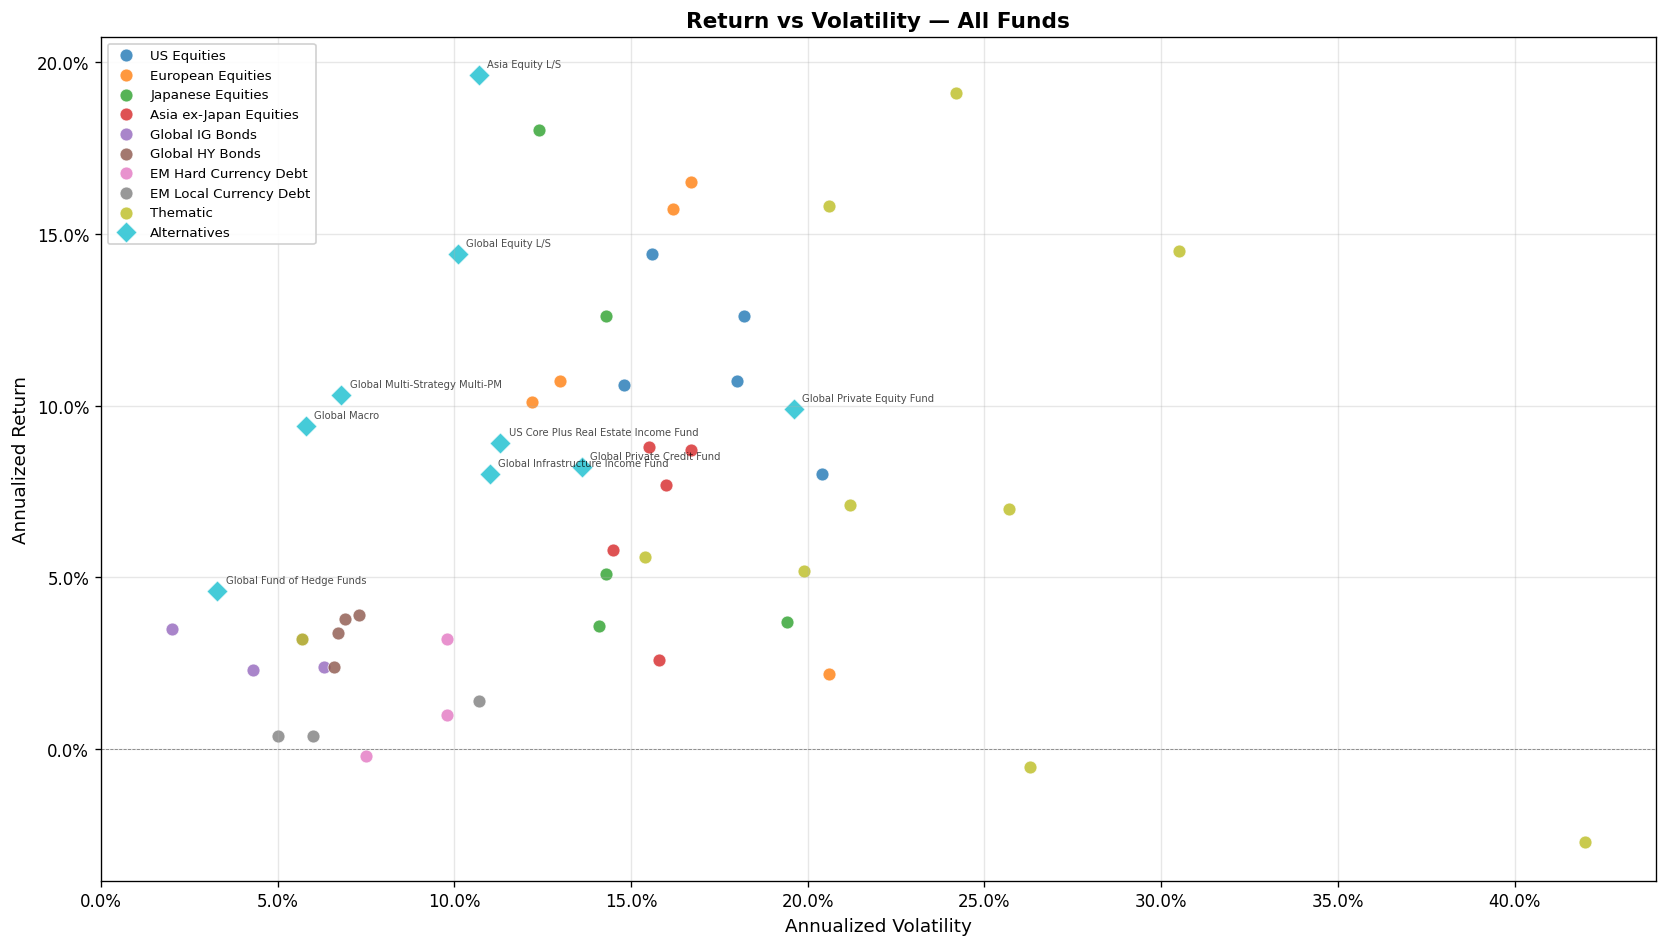

In [ ]:
# ── 8a: Return vs Volatility Scatter (All Funds) ──

fig, ax = plt.subplots(figsize=(14, 8))

colors = {
    "US Equities": "#1f77b4", "European Equities": "#ff7f0e", "Japanese Equities": "#2ca02c",
    "Asia ex-Japan Equities": "#d62728", "Global IG Bonds": "#9467bd", "Global HY Bonds": "#8c564b",
    "EM Hard Currency Debt": "#e377c2", "EM Local Currency Debt": "#7f7f7f",
    "Thematic": "#bcbd22",
}

for ac in funds["Asset Class"].unique():
    subset = funds[funds["Asset Class"] == ac]
    ax.scatter(subset["Volatility"], subset["Return"], label=ac,
               c=colors.get(ac, "#333"), s=60, alpha=0.8, edgecolors='white', linewidth=0.5)

ax.scatter(alts["Volatility"], alts["Return"], label="Alternatives",
           c="#17becf", s=80, marker="D", alpha=0.8, edgecolors='white', linewidth=0.5)

for _, row in alts.iterrows():
    ax.annotate(row["Fund"], (row["Volatility"], row["Return"]),
                fontsize=6, alpha=0.7, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel("Annualized Volatility", fontsize=11)
ax.set_ylabel("Annualized Return", fontsize=11)
ax.set_title("Return vs Volatility — All Funds", fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
ax.axhline(y=0, color='gray', linewidth=0.5, linestyle='--')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


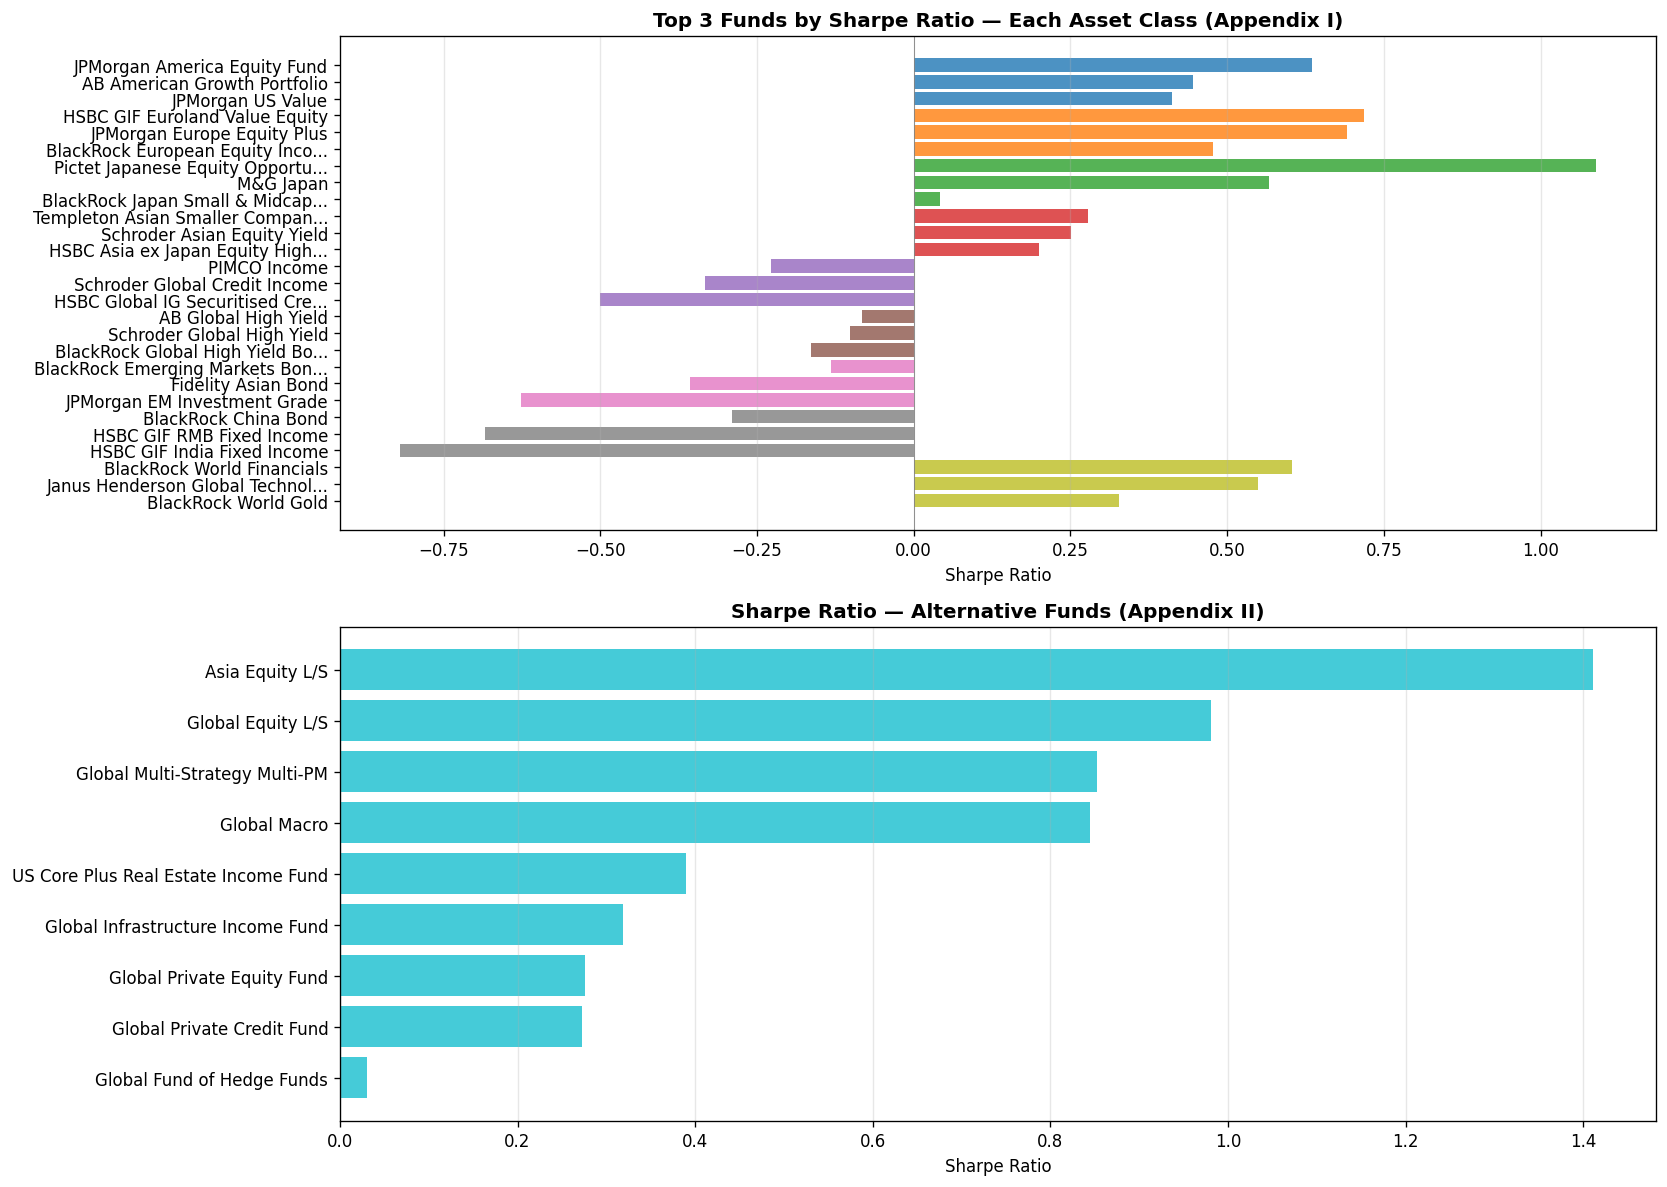

In [ ]:
# ── 8b: Sharpe Ratio Comparison by Asset Class ──

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

top_by_class = []
for ac in funds["Asset Class"].unique():
    subset = funds[funds["Asset Class"] == ac].nlargest(3, "Sharpe")
    top_by_class.append(subset)
top_df = pd.concat(top_by_class)

short_names = top_df["Fund"].apply(lambda x: x[:30] + "..." if len(x) > 30 else x)
bar_colors = [colors.get(ac, "#333") for ac in top_df["Asset Class"]]

axes[0].barh(short_names, top_df["Sharpe"], color=bar_colors, alpha=0.8)
axes[0].set_xlabel("Sharpe Ratio", fontsize=10)
axes[0].set_title("Top 3 Funds by Sharpe Ratio — Each Asset Class (Appendix I)", fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='gray', linewidth=0.5)
axes[0].grid(True, axis='x', alpha=0.3)
axes[0].invert_yaxis()

alt_sorted = alts.sort_values("Sharpe", ascending=True)
axes[1].barh(alt_sorted["Fund"], alt_sorted["Sharpe"], color="#17becf", alpha=0.8)
axes[1].set_xlabel("Sharpe Ratio", fontsize=10)
axes[1].set_title("Sharpe Ratio — Alternative Funds (Appendix II)", fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='gray', linewidth=0.5)
axes[1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# ── 8c: Current vs Proposed Portfolio (runs only if both are available) ──

if fund_selection or alt_selection:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Return comparison
    metrics = ["Expected Return", "Volatility", "Income Yield"]
    current_vals = [port_return, port_vol, port_yield]

    # Recalculate proposed
    pf_rows = []
    for isin, (ac, w, y) in fund_selection.items():
        if isin in funds.index:
            pf_rows.append({"w": w, "r": funds.loc[isin,"Return"], "v": funds.loc[isin,"Volatility"], "y": y})
    for fname, (w, y) in alt_selection.items():
        m = alts[alts["Fund"]==fname]
        if not m.empty:
            pf_rows.append({"w": w, "r": m.iloc[0]["Return"], "v": m.iloc[0]["Volatility"], "y": y})

    if pf_rows:
        pdf = pd.DataFrame(pf_rows)
        prop_return = (pdf["w"] * pdf["r"]).sum()
        prop_yield = (pdf["w"] * pdf["y"]).sum()
        proposed_vals = [prop_return, 0, prop_yield]  # vol=0 placeholder if no corr matrix

        x = np.arange(len(metrics))
        width = 0.35
        for i, (ax, metric) in enumerate(zip(axes, metrics)):
            ax.bar(["Current", "Proposed"], [current_vals[i], proposed_vals[i]],
                   color=["#d62728", "#2ca02c"], alpha=0.8, width=0.5)
            ax.set_title(metric, fontsize=11, fontweight='bold')
            ax.yaxis.set_major_formatter(PercentFormatter(1.0))
            ax.grid(True, axis='y', alpha=0.3)

        plt.suptitle("Current vs Proposed Portfolio", fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print("⚠ No valid funds to compare.")
else:
    print("⚠ Fund selection not yet defined. Fill in Cell 2 first.")


⚠ Fund selection not yet defined. Fill in Cell 2 first.


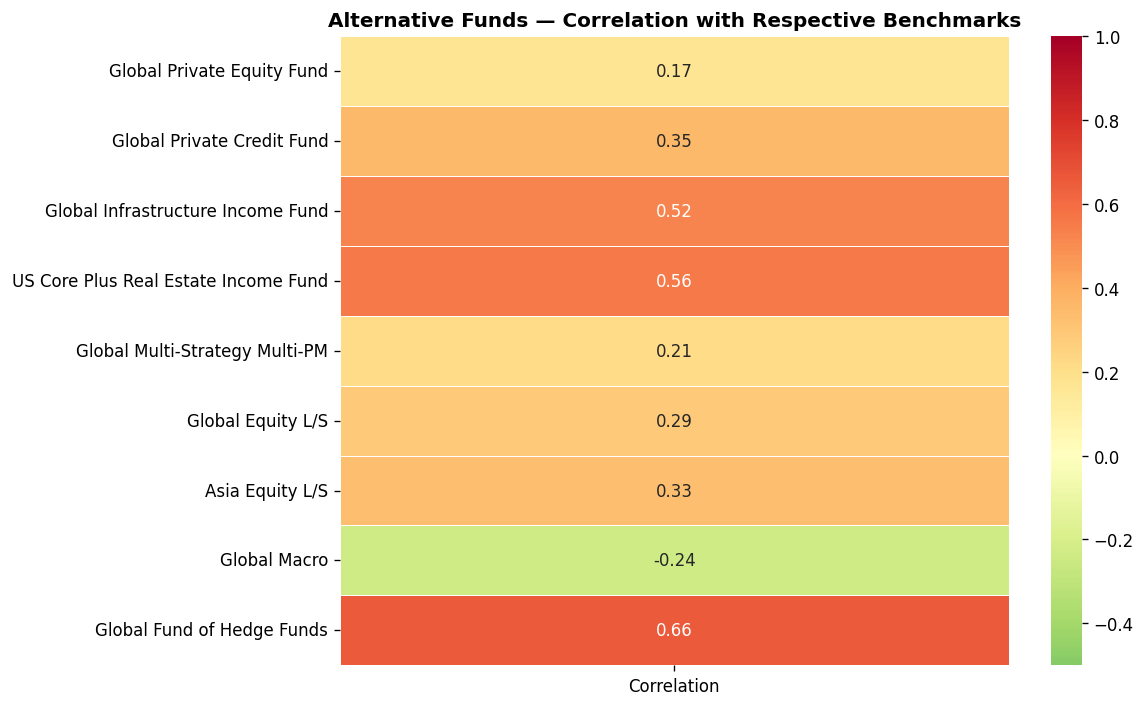


Benchmark mapping:
  Global Private Equity Fund                    → MSCI World
  Global Private Credit Fund                    → ICE BofA US High Yield
  Global Infrastructure Income Fund             → S&P Global Infra. Index
  US Core Plus Real Estate Income Fund          → D.J. US Real Estate
  Global Multi-Strategy Multi-PM                → MSCI World
  Global Equity L/S                             → MSCI World
  Asia Equity L/S                               → MSCI Asia Pacific
  Global Macro                                  → MSCI World
  Global Fund of Hedge Funds                    → MSCI World


In [ ]:
# ── 8d: Correlation Heatmap (Alternatives vs Benchmarks) ──

corr_data = alts[["Fund","Correlation","Benchmark"]].copy()
corr_pivot = corr_data.set_index("Fund")

fig, ax = plt.subplots(figsize=(10, 6))
corr_vals = corr_data[["Fund","Correlation"]].set_index("Fund")
sns.heatmap(corr_vals, annot=True, fmt=".2f", cmap="RdYlGn_r", center=0,
            ax=ax, vmin=-0.5, vmax=1.0, linewidths=0.5)
ax.set_title("Alternative Funds — Correlation with Respective Benchmarks", fontsize=12, fontweight='bold')
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("\nBenchmark mapping:")
for _, row in corr_data.iterrows():
    print(f"  {row['Fund']:45s} → {row['Benchmark']}")


In [ ]:
# ── 8e: Efficient Frontier with Current & Proposed Portfolio ──

if new_portfolio_corr is not None and (fund_selection or alt_selection):
    pf_rows = []
    for isin, (ac, w, y) in fund_selection.items():
        if isin in funds.index:
            pf_rows.append({"w": w, "r": funds.loc[isin,"Return"], "v": funds.loc[isin,"Volatility"]})
    for fname, (w, y) in alt_selection.items():
        m = alts[alts["Fund"]==fname]
        if not m.empty:
            pf_rows.append({"w": w, "r": m.iloc[0]["Return"], "v": m.iloc[0]["Volatility"]})

    if pf_rows:
        pdf = pd.DataFrame(pf_rows)
        n_assets = len(pdf)
        ret_arr = pdf["r"].values
        vol_arr = pdf["v"].values

        n_portfolios = 5000
        results = np.zeros((n_portfolios, 2))
        for i in range(n_portfolios):
            w_rand = np.random.dirichlet(np.ones(n_assets))
            p_ret = w_rand @ ret_arr
            cov_mat = np.outer(vol_arr, vol_arr) * new_portfolio_corr
            p_vol = np.sqrt(w_rand @ cov_mat @ w_rand)
            results[i] = [p_vol, p_ret]

        prop_w = pdf["w"].values
        prop_ret = prop_w @ ret_arr
        prop_cov = np.outer(vol_arr, vol_arr) * new_portfolio_corr
        prop_vol = np.sqrt(prop_w @ prop_cov @ prop_w)

        fig, ax = plt.subplots(figsize=(12, 7))
        sharpes = (results[:,1] - rf_rate) / results[:,0]
        scatter = ax.scatter(results[:,0], results[:,1], c=sharpes, cmap="viridis",
                            s=3, alpha=0.5, label="Random Portfolios")
        plt.colorbar(scatter, ax=ax, label="Sharpe Ratio")

        ax.scatter(port_vol, port_return, c="red", s=150, marker="X",
                  zorder=5, edgecolors="white", linewidth=1.5, label="Current Portfolio")
        ax.scatter(prop_vol, prop_ret, c="lime", s=150, marker="*",
                  zorder=5, edgecolors="black", linewidth=1, label="Proposed Portfolio")

        ax.set_xlabel("Volatility", fontsize=11)
        ax.set_ylabel("Expected Return", fontsize=11)
        ax.set_title("Efficient Frontier — Current vs Proposed", fontsize=13, fontweight="bold")
        ax.xaxis.set_major_formatter(PercentFormatter(1.0))
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("⚠ Requires new_portfolio_corr and fund_selection to be set in Cell 2.")

⚠ Requires new_portfolio_corr and fund_selection to be set in Cell 2.


In [ ]:
# ── 8f: Diversification Benefit — Equity-Only vs Diversified ──

if new_portfolio_corr is not None and (fund_selection or alt_selection):
    pf_rows_div = []
    eq_rows = []
    for isin, (ac, w, y) in fund_selection.items():
        if isin in funds.index:
            r = funds.loc[isin, "Return"]
            v = funds.loc[isin, "Volatility"]
            pf_rows_div.append({"w": w, "r": r, "v": v, "ac": ac})
            if "Equit" in ac or "Thematic" in ac:
                eq_rows.append({"w": w, "r": r, "v": v})
    for fname, (w, y) in alt_selection.items():
        m = alts[alts["Fund"]==fname]
        if not m.empty:
            pf_rows_div.append({"w": w, "r": m.iloc[0]["Return"], "v": m.iloc[0]["Volatility"], "ac": m.iloc[0]["Type"]})

    if pf_rows_div and eq_rows:
        div_df = pd.DataFrame(pf_rows_div)
        eq_df = pd.DataFrame(eq_rows)

        div_ret = (div_df["w"] * div_df["r"]).sum()
        div_vol_arr = div_df["v"].values
        div_w_arr = div_df["w"].values
        div_cov = np.outer(div_vol_arr, div_vol_arr) * new_portfolio_corr
        div_vol = np.sqrt(div_w_arr @ div_cov @ div_w_arr)

        eq_w_norm = eq_df["w"].values / eq_df["w"].values.sum()
        eq_ret = eq_w_norm @ eq_df["r"].values
        eq_vol_simple = np.sqrt(np.sum((eq_w_norm * eq_df["v"].values)**2))

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].bar(["Equity-Only", "Diversified"], [eq_vol_simple, div_vol],
                   color=["#d62728", "#2ca02c"], alpha=0.8, width=0.5)
        axes[0].set_title("Portfolio Volatility", fontsize=12, fontweight="bold")
        axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
        axes[0].grid(True, axis="y", alpha=0.3)
        reduction = (eq_vol_simple - div_vol) / eq_vol_simple * 100
        axes[0].annotate(f"-{reduction:.1f}%", xy=(1, div_vol), fontsize=14,
                        fontweight="bold", color="#2ca02c", ha="center",
                        xytext=(0, 15), textcoords="offset points")

        eq_sharpe = (eq_ret - rf_rate) / eq_vol_simple if eq_vol_simple > 0 else 0
        div_sharpe = (div_ret - rf_rate) / div_vol if div_vol > 0 else 0
        axes[1].bar(["Equity-Only", "Diversified"], [eq_sharpe, div_sharpe],
                   color=["#d62728", "#2ca02c"], alpha=0.8, width=0.5)
        axes[1].set_title("Sharpe Ratio", fontsize=12, fontweight="bold")
        axes[1].grid(True, axis="y", alpha=0.3)
        improvement = div_sharpe - eq_sharpe
        axes[1].annotate(f"+{improvement:.3f}", xy=(1, div_sharpe), fontsize=14,
                        fontweight="bold", color="#2ca02c", ha="center",
                        xytext=(0, 15), textcoords="offset points")

        plt.suptitle("Diversification Benefit — Equity-Only vs Diversified Portfolio",
                    fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()
    else:
        print("⚠ Need both equity and non-equity funds selected to show diversification benefit.")
else:
    print("⚠ Requires new_portfolio_corr and fund_selection to be set in Cell 2.")

⚠ Requires new_portfolio_corr and fund_selection to be set in Cell 2.
